# asymptotics — ODE Perturbation Theory

This notebook covers regular perturbation theory for **ordinary differential equations** using `asymptotics.ODE`.

The workflow is identical to algebraic equations — write everything as strings, call `expand_regular`, inspect the result:

```python
from asymptotics import ODE

eq  = ODE("u'' + u + eps*u**3", dependent="u", small_param="eps", independent="t",
          conditions=["u(0) = 1", "u'(0) = 0"])
sol = eq.expand_regular(order=2)
sol.show()
```

**Covered here:**
1. First-order IVP
2. Second-order IVP — the Duffing oscillator (secular terms)
3. Second-order IVP with damping
4. Linear BVP
5. Nonlinear BVP
6. Error checking

In [1]:
from asymptotics import ODE
%config InlineBackend.figure_format = 'svg'

---
## Example 1 — First-order IVP

$$u' + u + \varepsilon u^2 = 0, \qquad u(0) = 1$$

When $\varepsilon = 0$: $u_0' + u_0 = 0 \implies u_0 = e^{-t}$.

The nonlinear term $\varepsilon u^2$ perturbs this exponential decay.

In [2]:
from asymptotics import ODE
eq = ODE(
    "u' + u + eps*u**2",
    small_param = "eps",
    conditions  = ["u(0) = 1"])

sol = eq.expand_regular(order=2)
sol.show()

  ℹ️  dependent = 'u' (inferred from conditions), independent = 't' (inferred from equation)
     To override: ODE(..., dependent='u', independent='t')


<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

...

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

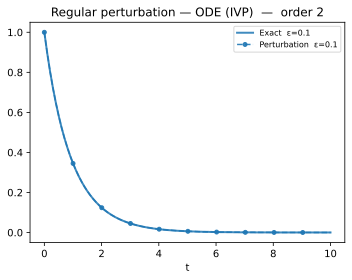

In [3]:
result = sol.compare_numeric(eps=[0.1])

In [4]:
sol.eval(eps=0.1, at=[i*0.5 for i in range(21)])

array([1.00000000e+00, 5.83604557e-01, 3.46094985e-01, 2.07142501e-01,
       1.24645146e-01, 7.52419154e-02, 4.55057665e-02, 2.75528448e-02,
       1.66941298e-02, 1.01190733e-02, 6.13516682e-03, 3.72029883e-03,
       2.25615617e-03, 1.36831053e-03, 8.29879119e-04, 5.03331251e-04,
       3.05279995e-04, 1.85159528e-04, 1.12304140e-04, 6.81156134e-05,
       4.13141010e-05])

In [5]:
sol.to_latex(show_orders=True)

% Regular perturbation — ODE (IVP)

% Particular solutions at each order

\begin{align}
  u_{0}(t) &= e^{- t} \\
  u_{1}(t) &= - e^{- t} + e^{- 2 t} \\
  u_{2}(t) &= e^{- t} - 2 e^{- 2 t} + e^{- 3 t}
\end{align}


% Expansion expansion

\begin{align}
  u(t,\varepsilon) &= \varepsilon^{2} \left(e^{- t} - 2 e^{- 2 t} + e^{- 3 t}\right) + \varepsilon \left(- e^{- t} + e^{- 2 t}\right) + e^{- t} + \mathcal{O}(\varepsilon^{3})
\end{align}


'% Regular perturbation — ODE (IVP)\n\n% Particular solutions at each order\n\n\\begin{align}\n  u_{0}(t) &= e^{- t} \\\\\n  u_{1}(t) &= - e^{- t} + e^{- 2 t} \\\\\n  u_{2}(t) &= e^{- t} - 2 e^{- 2 t} + e^{- 3 t}\n\\end{align}\n\n\n% Expansion expansion\n\n\\begin{align}\n  u(t,\\varepsilon) &= \\varepsilon^{2} \\left(e^{- t} - 2 e^{- 2 t} + e^{- 3 t}\\right) + \\varepsilon \\left(- e^{- t} + e^{- 2 t}\\right) + e^{- t} + \\mathcal{O}(\\varepsilon^{3})\n\\end{align}'

In [6]:
eq  = ODE(equation = "u'' + u + eps*u**3", 
          small_param="eps", 
          conditions= ["u(0) = 1", "u'(0) = 0"])

# Regular perturbation
sol = eq.expand_regular(order=2)
sol.show()

  ℹ️  dependent = 'u' (inferred from conditions), independent = 't' (inferred from equation)
     To override: ODE(..., dependent='u', independent='t')


<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

...

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

...

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

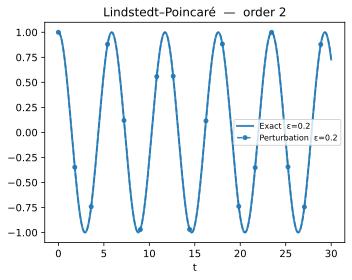

In [7]:
sol = eq.expand_lindstedt(order=2)
result = sol.compare_numeric(eps=0.2, plot_range=[0, 30])
sol.show()

---
## Example 2 — Duffing oscillator (secular terms)

$$u'' + u + \varepsilon u^3 = 0, \qquad u(0) = 1, \quad u'(0) = 0$$

The **Duffing oscillator** — a nonlinear spring. The unperturbed solution is $u_0 = \cos t$.

⚠️ **Secular terms appear at $\mathcal{O}(\varepsilon)$** — terms like $t\sin t$ that grow without bound. This means the regular perturbation expansion is only valid for small $t$. For a **uniformly valid** expansion, use Lindstedt–Poincaré (coming soon).

In [8]:
eq = ODE(
    "u'' + u + eps*u**3",
    small_param = "eps",
    conditions  = ["u(0) = 1", "u'(0) = 0"])

sol = eq.expand_regular(order=2)
sol.show()

  ℹ️  dependent = 'u' (inferred from conditions), independent = 't' (inferred from equation)
     To override: ODE(..., dependent='u', independent='t')


<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

...

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

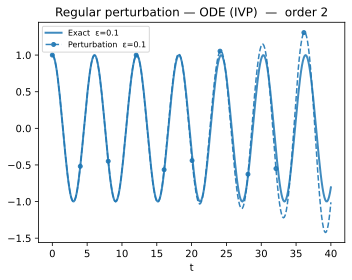

In [9]:
result = sol.compare_numeric(eps=0.1, plot_range=[0, 40])

---
## Example 3 — Second-order IVP with weak damping

$$u'' + \varepsilon u' + u = 0, \qquad u(0) = 1, \quad u'(0) = 0$$

Weak damping — the $\varepsilon u'$ term gradually suppresses oscillations. Unperturbed: $u_0 = \cos t$.

In [10]:
eq = ODE(
    "u'' + eps*u' + u",
    small_param = "eps",
    conditions  = ["u(0) = 1", "u'(0) = 0"])

sol = eq.expand_regular(order=2)
sol.show()

  ℹ️  dependent = 'u' (inferred from conditions), independent = 't' (inferred from equation)
     To override: ODE(..., dependent='u', independent='t')


<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

...

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

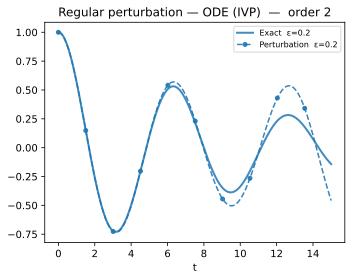

In [11]:
result = sol.compare_numeric(eps=0.2, plot_range=[0, 15])

---
## Example 4 — Linear BVP

$$u'' + \varepsilon u = 0, \qquad u(0) = 0, \quad u(1) = 1$$

The unperturbed problem $u_0'' = 0$ with $u_0(0)=0$, $u_0(1)=1$ gives $u_0 = t$.

Each order correction satisfies **homogeneous** boundary conditions $u_k(0) = u_k(1) = 0$.

In [21]:
eq = ODE(
    "u'' + eps*u",
    small_param = "eps",
    conditions  = ["u(0) = 0", "u(1) = 0.8"])

sol = eq.expand_regular(order=3)
sol.show()

  ℹ️  dependent = 'u' (inferred from conditions), independent = 'x' (inferred from equation)
     To override: ODE(..., dependent='u', independent='x')


<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

...

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

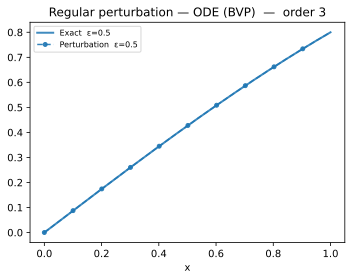

In [23]:
result = sol.compare_numeric(eps=0.5)

---
## Example 5 — Nonlinear BVP

$$u'' + \varepsilon u^2 = 0, \qquad u(0) = 0, \quad u(1) = 1$$

The nonlinear term $\varepsilon u^2$ bends the linear profile $u_0 = t$.

  ℹ️  dependent = 'u' (inferred from conditions), independent = 'x' (inferred from equation)
     To override: ODE(..., dependent='u', independent='x')


<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

...

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

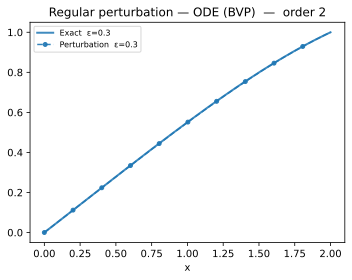

In [25]:
eq = ODE(
    "u'' + eps*u**2",
    small_param = "eps",
    conditions  = ["u(0) = 0", "u(2) = 1"])

sol = eq.expand_regular(order=2)
sol.compare_numeric(eps=0.3,plot_range=[0,2])
sol.show()

---
## Example 6 — Error checking

asymptotics catches common mistakes with clear messages.

In [17]:
from asymptotics import ODE
from asymptotics.core.conditions import ConditionError

# 1. Too many conditions
try:
    ODE("u'' + u", dependent="u", small_param="eps", independent="t",
        conditions=["u(0) = 1", "u'(0) = 0", "u(1) = 0"])
except ConditionError as e:
    print("Too many conditions:", e)

# 2. Too few conditions
try:
    ODE("u'' + u", dependent="u", small_param="eps", independent="t",
        conditions=["u(0) = 1"])
except ConditionError as e:
    print("Too few conditions:", e)

# 3. Conflicting conditions
try:
    ODE("u'' + u", dependent="u", small_param="eps", independent="t",
        conditions=["u(0) = 1", "u(0) = 2"])
except ConditionError as e:
    print("Conflicting conditions:", e)

# 4. Wrong variable name
try:
    ODE("u' + u", dependent="u", small_param="eps", independent="t",
        conditions=["v(0) = 1"])
except ConditionError as e:
    print("Wrong variable:", e)

# 5. No derivatives found
try:
    ODE("u + eps*u", dependent="u", small_param="eps", independent="t",
        conditions=["u(0) = 1"])
except ValueError as e:
    print("No derivatives:", e)

Too many conditions: 

  3 condition(s) provided but the ODE is order 2 — need exactly 2.

  Hint: for a 2nd-order ODE you need 2 conditions, e.g.:
    IVP: ["u(0) = 1", "u'(0) = 0"]
    BVP: ["u(0) = 0", "u(1) = 1"]

Too few conditions: 

  1 condition(s) provided but the ODE is order 2 — need exactly 2.

  Hint: for a 2nd-order ODE you need 2 conditions, e.g.:
    IVP: ["u(0) = 1", "u'(0) = 0"]
    BVP: ["u(0) = 0", "u(1) = 1"]

Conflicting conditions: 

  Conflicting conditions at t=0:
    u(0) = 1
    u(0) = 2

Wrong variable: 

  Condition 'v(0) = 1' refers to variable 'v'
  but the dependent variable is 'u'.

No derivatives: 

  No derivatives of 'u' found in equation 'u + eps*u'.
  Use prime notation: u' for first derivative, u'' for second.



---
## API quick reference

```python
from asymptotics import ODE

# IVP — 1st order
eq = ODE("u' + u + eps*u**2",
         dependent="u", small_param="eps", independent="t",
         conditions=["u(0) = 1"])

# IVP — 2nd order
eq = ODE("u'' + u + eps*u**3",
         dependent="u", small_param="eps", independent="t",
         conditions=["u(0) = 1", "u'(0) = 0"])

# BVP — 2nd order
eq = ODE("u'' + eps*u",
         dependent="u", small_param="eps", independent="t",
         conditions=["u(0) = 0", "u(1) = 1"])

# Expand
sol = eq.expand_regular(order=2)

# Display
sol.show()                          # full hierarchy (LaTeX in Jupyter)
sol.show(orders=[0, 1])             # specific orders
sol.show(mode='text')               # plain text

# Access results
sol[k].ode                          # ODE at order k
sol[k].general_solution             # with free constants
sol[k].particular_solution         # constants fixed by BCs/ICs
sol[k].secular                      # True if secular terms detected
sol.expansion                       # full expansion u(t,ε)
sol.small_param                     # the ε symbol
sol.independent                     # the t symbol
sol._problem_type                   # 'ivp' or 'bvp'
```

**Supported derivative notation:**
- `u'`  → $u'$ (first derivative)
- `u''` → $u''$ (second derivative)

**Standard functions work out of the box:** `sin`, `cos`, `exp`, `log`, `tan`, `sqrt`, ...

In [18]:
eq = ODE(
    "u'' + u + eps*u**3",
    dependent   = "u",
    small_param = "eps",
    independent = "t",
    conditions  = ["u(0) = 1", "u'(0) = 0"])

sol = eq.expand_lindstedt(order=3)
sol.show()

  ℹ️  dependent = 'u' (supplied), independent = 't' (supplied)
     To override: ODE(..., dependent='u', independent='t')


<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

...

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

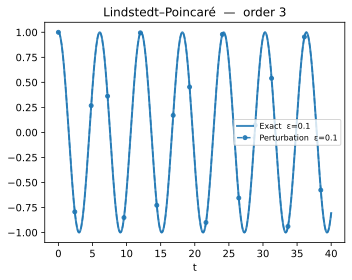

In [19]:
result = sol.compare_numeric(eps=0.1, plot_range=[0, 40])

# Example: fourth order ODE

In [20]:
eq = ODE("u'''' + u'' + eps*u", small_param="eps",
         conditions=["u(0)=0", "u'(0)=1", "u''(0)=0", "u'''(0)=0"])
sol = eq.expand_regular(order=2)
sol.show()

  ℹ️  dependent = 'u' (inferred from conditions), independent = 't' (inferred from equation)
     To override: ODE(..., dependent='u', independent='t')


<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

...

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

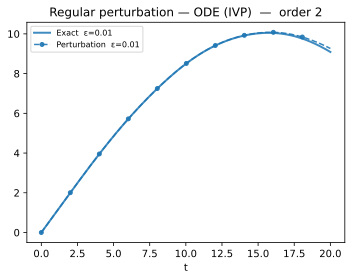

In [21]:
result = sol.compare_numeric(eps=0.01, plot_range = [0,20]);